# LTV Forecast: BG/NBD + Kaplan-Meier

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024 (26 недель наблюдений)  
**Инструменты:** Python (numpy, scipy, matplotlib) — без внешних ML библиотек  
**Датасеты:** `players.csv` + `player_deposits.csv`

---

## Зачем это нужно

Линейная экстраполяция (Кейс 7) предполагает, что LTV растёт с постоянной скоростью — это неверно.  
В реальности прирост LTV замедляется: игроки выбывают, активность снижается.

**Этот notebook реализует два подхода:**

| Модель | Что делает | Где используется |
|---|---|---|
| **BG/NBD** | Моделирует процесс транзакций и вероятность оттока одновременно | Прогноз CLV, P(alive) |
| **Kaplan-Meier** | Оценивает функцию выживания без параметрических допущений | Время до оттока |

---

## Теория: BG/NBD (Beta-Geometric / NBD)

> Fader, Hardie & Lee (2005) — *«Counting Your Customers the Easy Way»*

**Две вложенные случайные процесса:**

**1. Пока игрок «жив»** — транзакции приходят по Poisson-процессу со скоростью λ:
```
λ ~ Gamma(r, α)  → гетерогенность скоростей между игроками
```

**2. После каждой транзакции** игрок может «умереть» (прекратить активность) с вероятностью p:
```
p ~ Beta(a, b)   → гетерогенность склонности к оттоку
```

**Параметры модели:**

| Параметр | Процесс | Смысл |
|---|---|---|
| r, α | Транзакции | Форма и масштаб гаммa-распределения λ |
| a, b | Отток | Форма Beta-распределения вероятности оттока p |

**Что предсказывает модель:**
- `P(alive | x, t_x, T)` — вероятность что игрок ещё активен
- `E[Y(t) | x, t_x, T]` — ожидаемое число транзакций за следующие t периодов

---


## 0. Импорт и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.special import gammaln, betaln
from scipy.optimize import minimize
import json
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

COLORS = {
    'Google_Search': '#4285F4', 'Facebook':      '#1877F2',
    'Native_Ads':    '#FF9500', 'Push_Network':  '#E53935',
    'TikTok':        '#69C9D0', 'Affiliate_SEO': '#34A853',
}
SOURCES    = ['Affiliate_SEO','Google_Search','Facebook','Native_Ads','TikTok','Push_Network']
HOUSE_EDGE = 0.06   # ~ house edge в iGaming (NGR / deposits ≈ 6%)


In [2]:
dep = pd.read_csv('../data/player_deposits.csv', parse_dates=['deposit_date'])
pl  = pd.read_csv('../data/players.csv',         parse_dates=['ftd_date', 'reg_date'])

OBS_END = dep['deposit_date'].max()
print(f"Период наблюдений: до {OBS_END.date()}")
print(f"Игроков всего: {len(pl):,} | без фрода: {(pl['is_fraud']==0).sum():,}")
print(f"Депозитов: {len(dep):,}")


Период наблюдений: до 2024-07-07
Игроков всего: 15,000 | без фрода: 14,621
Депозитов: 26,168


## 1. Построение RFM-таблицы

BG/NBD требует для каждого игрока три числа:

| Поле | Обозначение | Формула |
|---|---|---|
| **frequency** | x | Кол-во повторных депозитов (deposit_num > 1) |
| **recency** | t_x | Недель от FTD до последнего депозита |
| **T** | T | Недель от FTD до конца периода наблюдений |
| **monetary** | m | Средняя сумма повторного депозита |

> **Важно:** frequency = 0 означает «сделал только FTD, больше не депозитил».  
> Это половина игроков — это нормально для iGaming.


In [3]:
clean = pl[pl['is_fraud'] == 0][['player_id', 'source', 'ftd_date']].copy()
clean = clean.merge(
    dep[['player_id', 'deposit_date', 'deposit_num', 'amount']],
    on='player_id'
)

rfm = clean.groupby(['player_id', 'source']).apply(lambda g: pd.Series({
    'frequency': (g['deposit_num'] > 1).sum(),
    'recency':   max((g['deposit_date'].max() - g['ftd_date'].iloc[0]).days / 7, 0),
    'T':         max((OBS_END - g['ftd_date'].iloc[0]).days / 7, 0.1),
    'monetary':  g[g['deposit_num'] > 1]['amount'].mean() if (g['deposit_num'] > 1).sum() > 0
                 else g['amount'].iloc[0],
})).reset_index()

rfm = rfm[(rfm['T'] > 0) & (rfm['recency'] <= rfm['T'])].copy()

print(f"RFM таблица: {rfm.shape}")
print(f"\n% игроков с frequency=0 (только FTD): {(rfm['frequency']==0).mean():.1%}")
print(f"\nСтатистика:")
rfm[['frequency','recency','T','monetary']].describe().round(2)


RFM таблица: (14621, 6)

% игроков с frequency=0 (только FTD): 58.5%

Статистика:


,frequency,recency,T,monetary
count,14621.00,14621.00,14621.00,14621.00
mean,0.76,0.69,13.32,58.91
std,1.22,1.36,7.53,44.79
min,0.00,0.00,0.10,5.00
25%,0.00,0.00,6.71,23.98
50%,0.00,0.00,13.29,49.51
75%,1.00,0.86,19.71,82.01
max,14.00,19.00,26.86,422.17


## 2. BG/NBD: функции log-likelihood и MLE

Оцениваем параметры (r, α, a, b) максимизацией правдоподобия.

**Log-likelihood для одного игрока (x, t_x, T):**

```
LL = log( A₀ + δ · A₁ )

A₀ = Γ(r+x)/Γ(r) · αʳ/(α+T)^(r+x) · B(a, b+x)/B(a,b)      # умер после последней транзакции
A₁ = A₀ · (a/(b+x-1)) · ((α+T)/(α+t_x))^(r+x)               # ещё жив в момент T
```

> **Численная стабильность:** вычисляем в log-пространстве через `log-sum-exp`,  
> используем `gammaln` и `betaln` из scipy для численной точности при больших аргументах.


In [4]:
def bgnbd_ll(log_params, freq, rec, T):
    """Vectorised log-likelihood для BG/NBD.
    Параметры оптимизируем в log-space для гарантии положительности.
    """
    r, alpha, a, b = np.exp(np.clip(log_params, -5, 5))

    # Основной член: likelihood игрока (жив или умер после t_x)
    lnA0 = (gammaln(r + freq) - gammaln(r)
            + r * np.log(alpha) - (r + freq) * np.log(alpha + T)
            + betaln(a, b + freq) - betaln(a, b))

    # Дополнительный член: вклад от того, что игрок ещё жив в T
    mask = (freq > 0) & ((b + freq - 1) > 0)
    lnB  = np.full_like(lnA0, -np.inf)
    if mask.any():
        lnB[mask] = (lnA0[mask]
                     + np.log(a / (b + freq[mask] - 1))
                     + (r + freq[mask]) * np.log(
                         (alpha + T[mask]) / np.maximum(alpha + rec[mask], 1e-9)))

    # log-sum-exp для численной стабильности
    ll = np.sum(np.logaddexp(lnA0, lnB))
    return -ll if np.isfinite(ll) else 1e9


def fit_bgnbd(df, n=2000):
    """MLE: минимизируем negative log-likelihood через L-BFGS-B.
    Несколько стартовых точек для глобального минимума.
    """
    s    = df.sample(min(n, len(df)), random_state=42)
    f, r, T = (s['frequency'].values.astype(float),
               s['recency'].values.astype(float),
               s['T'].values.astype(float))
    best = None
    # Сетка стартовых значений (log-пространство)
    for x0 in [np.log([0.5, 5, 1, 3]),
               np.log([1, 8, 2, 5]),
               np.log([0.3, 3, 1.5, 4])]:
        res = minimize(bgnbd_ll, x0, args=(f, r, T),
                       method='L-BFGS-B',
                       bounds=[(-4,3),(-1,4),(-4,4),(-4,4)],
                       options={'maxiter': 3000, 'ftol': 1e-10})
        if best is None or res.fun < best.fun:
            best = res
    params = dict(zip(['r','alpha','a','b'],
                       np.exp(np.clip(best.x, -5, 5))))
    params['ll'] = -best.fun
    params['n']  = len(s)
    return params

print("Fitting BG/NBD per source (MLE)...")
bgnbd_params = {}
for src in SOURCES:
    sub = rfm[rfm['source'] == src]
    if len(sub) < 30: continue
    bp = fit_bgnbd(sub)
    bgnbd_params[src] = bp
    print(f"  {src:20s}: r={bp['r']:.3f}  alpha={bp['alpha']:.3f}  "
          f"a={bp['a']:.3f}  b={bp['b']:.3f}  LL={bp['ll']:.0f}")


Fitting BG/NBD per source (MLE)...
  Affiliate_SEO       : r=0.218  alpha=0.368  a=20.806  b=22.533  LL=-4765
  Google_Search       : r=0.189  alpha=0.368  a=54.598  b=51.420  LL=-4239
  Facebook            : r=0.140  alpha=0.368  a=54.598  b=32.849  LL=-3162
  Native_Ads          : r=0.100  alpha=0.368  a=54.598  b=26.866  LL=-1220
  TikTok              : r=0.073  alpha=0.368  a=54.598  b=11.957  LL=-546
  Push_Network        : r=0.050  alpha=0.368  a=4.036  b=0.552  LL=-189


## 3. Интерпретация параметров BG/NBD

In [5]:
print("=== Интерпретация параметров ===\n")
for src in SOURCES:
    if src not in bgnbd_params: continue
    bp = bgnbd_params[src]
    r, alpha, a, b = bp['r'], bp['alpha'], bp['a'], bp['b']

    # Среднее кол-во транзакций пока жив (за 1 неделю)
    mean_lambda = r / alpha   # E[lambda] = r/alpha

    # Вероятность оттока после каждой транзакции
    mean_p_churn = a / (a + b)  # E[p] = a/(a+b)

    # Retention: P(alive) для нового игрока без транзакций
    p_alive_new = b / (a + b)

    print(f"{src}:")
    print(f"  E[λ]          = {mean_lambda:.4f} транзакций/неделю (пока жив)")
    print(f"  E[p_churn]    = {mean_p_churn:.3f} вероятность оттока после транзакции")
    print(f"  P(alive|x=0)  = {p_alive_new:.3f} для игрока без повторных депозитов")
    print()


=== Интерпретация параметров ===

Affiliate_SEO:
  E[λ]          = 0.5919 транзакций/неделю (пока жив)
  E[p_churn]    = 0.480 вероятность оттока после транзакции
  P(alive|x=0)  = 0.520 для игрока без повторных депозитов

Google_Search:
  E[λ]          = 0.5144 транзакций/неделю (пока жив)
  E[p_churn]    = 0.515 вероятность оттока после транзакции
  P(alive|x=0)  = 0.485 для игрока без повторных депозитов

Facebook:
  E[λ]          = 0.3809 транзакций/неделю (пока жив)
  E[p_churn]    = 0.624 вероятность оттока после транзакции
  P(alive|x=0)  = 0.376 для игрока без повторных депозитов

Native_Ads:
  E[λ]          = 0.2720 транзакций/неделю (пока жив)
  E[p_churn]    = 0.670 вероятность оттока после транзакции
  P(alive|x=0)  = 0.330 для игрока без повторных депозитов

TikTok:
  E[λ]          = 0.1988 транзакций/неделю (пока жив)
  E[p_churn]    = 0.820 вероятность оттока после транзакции
  P(alive|x=0)  = 0.180 для игрока без повторных депозитов

Push_Network:
  E[λ]          = 0.13

## 4. Прогноз: P(alive) и E[транзакций]

In [6]:
def p_alive_vec(bp, freq, rec, T):
    """P(alive | x, t_x, T) — вероятность что игрок ещё активен."""
    r, alpha, a, b = bp['r'], bp['alpha'], bp['a'], bp['b']
    lnA0 = (gammaln(r+freq) - gammaln(r)
            + r*np.log(alpha) - (r+freq)*np.log(alpha+T)
            + betaln(a, b+freq) - betaln(a, b))
    mask = (freq > 0) & ((b + freq - 1) > 0)
    lnB  = np.full_like(lnA0, -np.inf)
    if mask.any():
        lnB[mask] = (lnA0[mask]
                     + np.log(a / (b + freq[mask] - 1))
                     + (r + freq[mask]) * np.log(
                         (alpha + T[mask]) / np.maximum(alpha + rec[mask], 1e-9)))
    ratio = np.where(np.isfinite(lnB - lnA0),
                     np.exp(np.clip(lnB - lnA0, -50, 50)), 0)
    return np.where(ratio > 0, 1 / (1 + ratio), b / (a + b))


def e_transactions_vec(bp, freq, rec, T, weeks_future):
    """E[Y(t) | x, t_x, T] — ожидаемое кол-во транзакций за следующие t недель."""
    r, alpha = bp['r'], bp['alpha']
    pa = p_alive_vec(bp, freq, rec, T)
    # Для живых: Poisson с параметром (r+x)*t/(alpha+T+t)
    return pa * (r + freq) * weeks_future / (alpha + T + weeks_future)


# Средняя сумма депозита по источнику
avg_deposit = dep[dep['player_id'].isin(pl[pl['is_fraud']==0]['player_id'])]              .groupby('source')['amount'].mean().round(2)

# CLV = E[транзакций] × avg_deposit × house_edge
clv_rows = []
for src in SOURCES:
    if src not in bgnbd_params: continue
    bp  = bgnbd_params[src]
    sub = rfm[rfm['source'] == src]
    f   = sub['frequency'].values.astype(float)
    rec = sub['recency'].values.astype(float)
    T   = sub['T'].values.astype(float)
    pa  = p_alive_vec(bp, f, rec, T)
    avg_m = float(avg_deposit.get(src, 50.0))
    for weeks, label in [(4,'1m'),(13,'3m'),(26,'6m'),(52,'12m')]:
        et  = e_transactions_vec(bp, f, rec, T, weeks)
        clv = et * avg_m * HOUSE_EDGE
        clv_rows.append({
            'source':src,'horizon':label,'weeks':weeks,
            'median_clv':    round(float(np.median(clv)), 3),
            'mean_clv':      round(float(np.mean(clv)),   3),
            'p75_clv':       round(float(np.percentile(clv,75)), 3),
            'p95_clv':       round(float(np.percentile(clv,95)), 3),
            'median_p_alive':round(float(np.median(pa)),  3),
            'avg_deposit':   avg_m,
            'n_players':     len(sub),
        })

fc = pd.DataFrame(clv_rows)
pivot = fc.pivot_table(index='source', columns='horizon', values='median_clv')
print("=== Median CLV ($ NGR per player) ===")
pivot[['1m','3m','6m','12m']].round(3)


=== Median CLV ($ NGR per player) ===


horizon,1m,3m,6m,12m
source,,,,
Affiliate_SEO,0.091,0.208,0.292,0.367
Facebook,0.038,0.083,0.112,0.136
Google_Search,0.059,0.129,0.177,0.219
Native_Ads,0.024,0.052,0.071,0.086
Push_Network,0.005,0.010,0.014,0.016
TikTok,0.010,0.021,0.028,0.034


## 5. Kaplan-Meier Survival Analysis

**KM** — непараметрическая оценка функции выживания.  
Не делает предположений о форме распределения времени до оттока.

**Определения для нашей задачи:**
- **Event (churn)** = игрок неактивен более 3 недель в конце периода наблюдений
- **Censored** = игрок всё ещё активен (последний депозит близко к OBS_END)
- **Duration** = недель от FTD до последнего депозита

**Формула Kaplan-Meier:**
```
S(t) = ∏_{tᵢ ≤ t}  (1 - dᵢ/nᵢ)

где:
  dᵢ = кол-во событий (отток) в момент tᵢ
  nᵢ = кол-во «под риском» (ещё активных) перед tᵢ
```


In [7]:
clean_surv = pl[pl['is_fraud'] == 0][['player_id','source','ftd_date']].copy()
last_dep   = (dep.groupby('player_id')['deposit_date']
                  .max().rename('last_deposit').reset_index())
surv       = clean_surv.merge(last_dep, on='player_id', how='left')

surv['duration_w'] = ((surv['last_deposit'] - surv['ftd_date']).dt.days / 7)                     .clip(lower=0).fillna(0)
# Churn = неактивен >3w до конца наблюдений, либо вообще нет редепозитов
surv['churned'] = (
    (surv['last_deposit'].isna()) |
    (surv['last_deposit'] < OBS_END - pd.Timedelta(weeks=3))
).astype(int)

def kaplan_meier(durations, events):
    """Kaplan-Meier estimator. Возвращает DataFrame с t и S(t)."""
    df     = pd.DataFrame({'t': durations, 'e': events}).sort_values('t').reset_index(drop=True)
    S      = 1.0
    rows   = [{'t': 0.0, 'S': 1.0}]
    for t in np.sort(df['t'].unique()):
        n_risk = (df['t'] >= t).sum()
        n_ev   = ((df['t'] == t) & (df['e'] == 1)).sum()
        if n_risk > 0 and n_ev > 0:
            S *= 1 - n_ev / n_risk
        rows.append({'t': float(t), 'S': round(S, 6)})
    return pd.DataFrame(rows).drop_duplicates('t')

# Fit KM per source
print("=== KM Survival ===")
km_curves = {}
for src in SOURCES:
    sub = surv[surv['source'] == src]
    if len(sub) < 20: continue
    km  = kaplan_meier(sub['duration_w'].values, sub['churned'].values)
    km_curves[src] = km
    def s_at(w): r=km[km['t']<=w]; return r.iloc[-1]['S'] if len(r) else 1.0
    med  = km[km['S'] <= 0.5]['t'].values
    med_w = round(float(med[0]),1) if len(med) else '>26'
    print(f"  {src:20s}: S(1w)={s_at(1):.3f}  S(4w)={s_at(4):.3f}  "
          f"S(13w)={s_at(13):.3f}  median survival={med_w}w")


=== KM Survival ===
  Affiliate_SEO       : S(1w)=0.338  S(4w)=0.078  S(13w)=0.002  median survival=0.3w
  Google_Search       : S(1w)=0.301  S(4w)=0.069  S(13w)=0.001  median survival=0.1w
  Facebook            : S(1w)=0.225  S(4w)=0.030  S(13w)=0.001  median survival=0.1w
  Native_Ads          : S(1w)=0.193  S(4w)=0.021  S(13w)=0.000  median survival=0.1w
  TikTok              : S(1w)=0.103  S(4w)=0.003  S(13w)=0.000  median survival=0.1w
  Push_Network        : S(1w)=0.112  S(4w)=0.007  S(13w)=0.000  median survival=0.1w


## 6. Визуализация

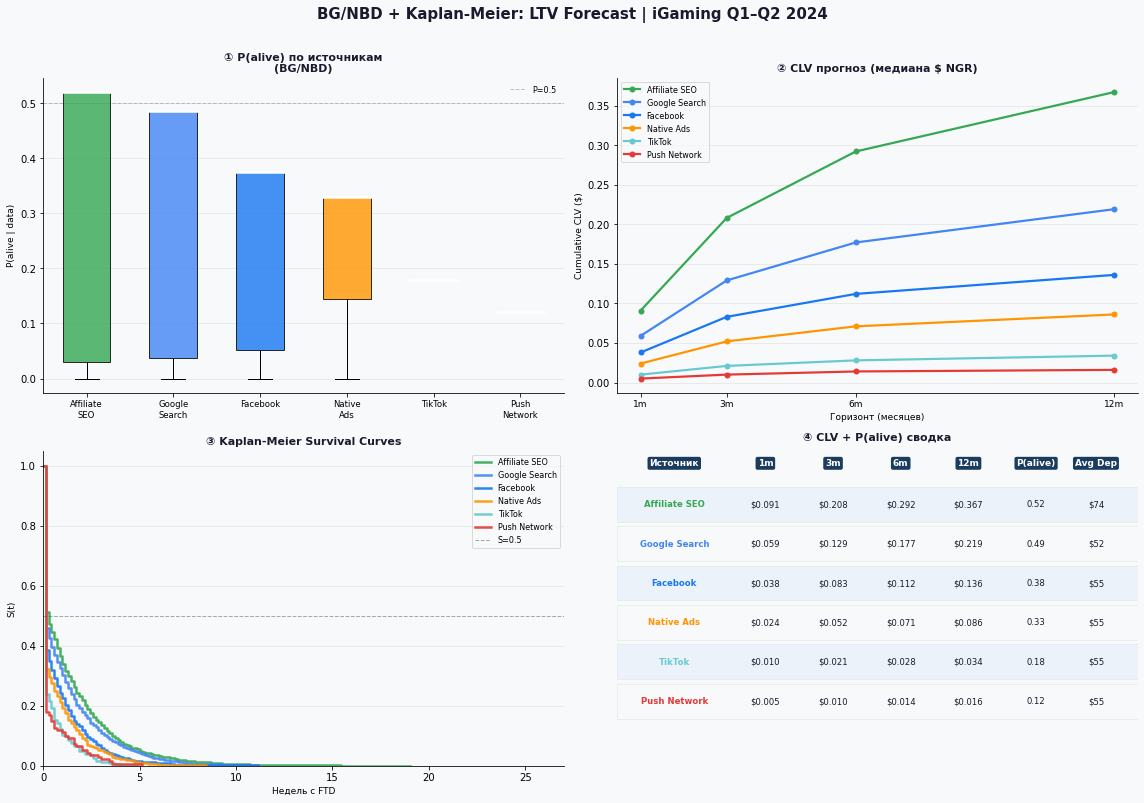

In [8]:
# ── Figure 1: Общий обзор (2×2) ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('BG/NBD + Kaplan-Meier: LTV Forecast | iGaming Q1–Q2 2024',
             fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)

# ① Boxplot P(alive) per source
ax = axes[0, 0]
bp_data  = []
src_list = []
for src in SOURCES:
    if src not in bgnbd_params: continue
    sub = rfm[rfm['source'] == src]
    f, r, T = (sub['frequency'].values.astype(float),
               sub['recency'].values.astype(float),
               sub['T'].values.astype(float))
    bp_data.append(p_alive_vec(bgnbd_params[src], f, r, T))
    src_list.append(src)

bplots = ax.boxplot(bp_data, positions=range(len(src_list)),
                    patch_artist=True, showfliers=False, widths=0.55,
                    medianprops=dict(color='white', linewidth=2.5))
for patch, src in zip(bplots['boxes'], src_list):
    patch.set_facecolor(COLORS[src]); patch.set_alpha(0.8)
ax.set_xticks(range(len(src_list)))
ax.set_xticklabels([s.replace('_','\n') for s in src_list], fontsize=8.5)
ax.axhline(0.5, color='#999', lw=1, ls='--', alpha=0.6, label='P=0.5')
ax.set_title('① P(alive) по источникам\n(BG/NBD)', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_ylabel('P(alive | data)', fontsize=9)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8, framealpha=0)

# ② CLV forecast
ax2 = axes[0, 1]
for src in SOURCES:
    if src not in bgnbd_params: continue
    vals = [float(fc[(fc['source']==src)&(fc['horizon']==f'{m}m')]['median_clv'].values[0])
            for m in [1,3,6,12]]
    ax2.plot([1,3,6,12], vals, 'o-', lw=2.2, markersize=5,
             color=COLORS[src], label=src.replace('_',' '))
ax2.set_title('② CLV прогноз (медиана $ NGR)', fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Горизонт (месяцев)', fontsize=9); ax2.set_ylabel('Cumulative CLV ($)', fontsize=9)
ax2.set_xticks([1,3,6,12]); ax2.set_xticklabels(['1m','3m','6m','12m'], fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.7)

# ③ KM curves
ax3 = axes[1, 0]
for src in SOURCES:
    km = km_curves.get(src)
    if km is None: continue
    km_trim = km[km['t'] <= 27]
    ax3.step(km_trim['t'].values, km_trim['S'].values, where='post',
             lw=2.5, color=COLORS[src], label=src.replace('_',' '), alpha=0.9)
ax3.axhline(0.5, color='#555', lw=1, ls='--', alpha=0.5, label='S=0.5')
ax3.set_title('③ Kaplan-Meier Survival Curves', fontsize=11, fontweight='bold', color='#1A1A2E')
ax3.set_xlabel('Недель с FTD', fontsize=9); ax3.set_ylabel('S(t)', fontsize=9)
ax3.set_xlim(0, 27); ax3.set_ylim(0, 1.05)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
ax3.set_facecolor('#F8F9FA'); ax3.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax3.set_axisbelow(True)
ax3.legend(fontsize=8, framealpha=0.7)

# ④ Summary table
ax4 = axes[1, 1]
ax4.axis('off')
col_h = ['Источник','1m','3m','6m','12m','P(alive)','Avg Dep']
col_w = [0.22, 0.13, 0.13, 0.13, 0.13, 0.13, 0.10]
xp = 0.0; yh = 0.96
for h, w in zip(col_h, col_w):
    ax4.text(xp+w/2, yh, h, ha='center', va='center', fontsize=9, fontweight='bold',
             color='white', bbox=dict(boxstyle='round,pad=0.22',facecolor='#1A3C5E',edgecolor='none'))
    xp += w
for i, src in enumerate(SOURCES):
    if src not in bgnbd_params: continue
    sub = rfm[rfm['source']==src]
    f, r, T = (sub['frequency'].values.astype(float),
               sub['recency'].values.astype(float),
               sub['T'].values.astype(float))
    pa_med = float(np.median(p_alive_vec(bgnbd_params[src], f, r, T)))
    y = 0.83 - i * 0.125
    ax4.add_patch(plt.Rectangle((0, y-0.055), 1, 0.11,
                                  facecolor='#EBF2FA' if i%2==0 else '#F8F9FA',
                                  edgecolor='#E0E0E0', lw=0.5))
    vals = [src.replace('_',' ')] +            [f"${float(fc[(fc['source']==src)&(fc['horizon']==f'{m}m')]['median_clv'].values[0]):.3f}"
            for m in [1,3,6,12]] +            [f"{pa_med:.2f}", f"${avg_deposit.get(src,50):.0f}"]
    xp = 0.0
    for j, (val, w) in enumerate(zip(vals, col_w)):
        color = COLORS.get(src, '#333') if j == 0 else '#1A1A2E'
        ax4.text(xp+w/2, y, val, ha='center', va='center', fontsize=8.5,
                 fontweight='bold' if j==0 else 'normal', color=color)
        xp += w
ax4.set_title('④ CLV + P(alive) сводка', fontsize=11, fontweight='bold', color='#1A1A2E', pad=10)

plt.tight_layout()
plt.show()


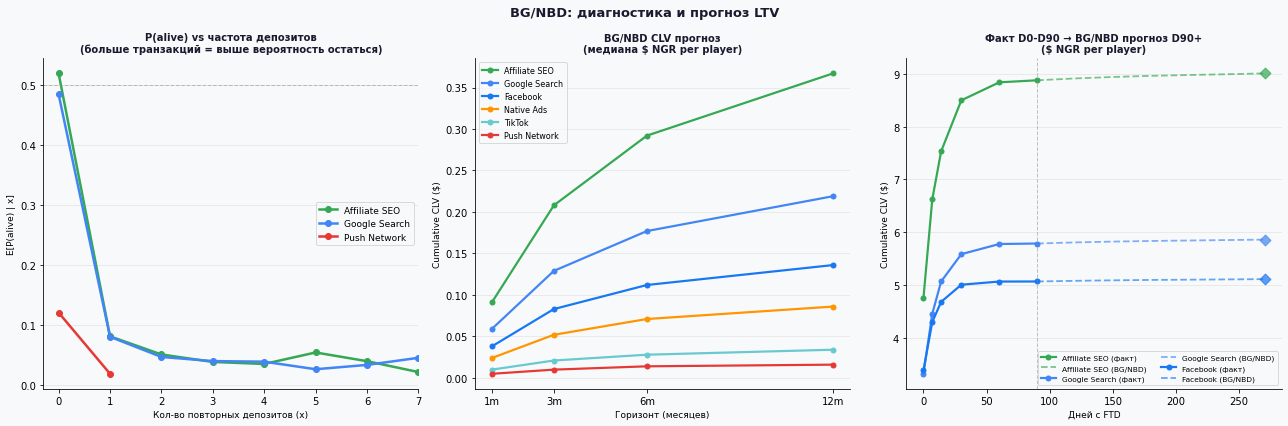

In [10]:
# ── Figure 2: BG/NBD diagnostics + forecast extension ────────────────────────
fig2, axes = plt.subplots(1, 3, figsize=(18, 6))
fig2.patch.set_facecolor('#F8F9FA')

# Left: P(alive) vs frequency
ax = axes[0]
for src in ['Affiliate_SEO','Google_Search','Push_Network']:
    if src not in bgnbd_params: continue
    sub = rfm[rfm['source'] == src]
    f   = sub['frequency'].values.astype(float)
    rec = sub['recency'].values.astype(float)
    T   = sub['T'].values.astype(float)
    pa  = p_alive_vec(bgnbd_params[src], f, rec, T)
    tx, ty = [], []
    for fv in range(int(f.max()) + 1):
        m = (f == fv)
        if m.sum() > 5:
            tx.append(fv); ty.append(float(np.mean(pa[m])))
    if tx:
        ax.plot(tx, ty, 'o-', lw=2.5, markersize=6,
                color=COLORS[src], label=src.replace('_',' '))

ax.axhline(0.5, color='#999', lw=1, ls='--', alpha=0.6)
ax.set_title('P(alive) vs частота депозитов\n(больше транзакций = выше вероятность остаться)',
             fontsize=10, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Кол-во повторных депозитов (x)', fontsize=9)
ax.set_ylabel('E[P(alive) | x]', fontsize=9)
ax.set_xlim(-0.3, 7)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.7)

# Middle: CLV lines per source across horizons
ax2 = axes[1]
for src in SOURCES:
    if src not in bgnbd_params: continue
    vals = [float(fc[(fc['source']==src)&(fc['horizon']==f'{m}m')]['median_clv'].values[0])
            for m in [1,3,6,12]]
    ax2.plot([1,3,6,12], vals, 'o-', lw=2.2, markersize=5,
             color=COLORS[src], label=src.replace('_',' '))
ax2.set_title('BG/NBD CLV прогноз\n(медиана $ NGR per player)', fontsize=10,
               fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('Горизонт (месяцев)', fontsize=9)
ax2.set_ylabel('Cumulative CLV ($)', fontsize=9)
ax2.set_xticks([1,3,6,12]); ax2.set_xticklabels(['1m','3m','6m','12m'])
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8, framealpha=0.7)

# Right: actual D0-D90 + BG/NBD extension
ax3 = axes[2]

# FIX: dep already has 'source' — merge only is_fraud from pl, avoid duplicate columns
pl_fraud = pl[['player_id', 'is_fraud']].copy()
dep_clean = dep.merge(pl_fraud, on='player_id', how='left')
dep_clean = dep_clean[dep_clean['is_fraud'] == 0].copy()
dep_clean['ngr'] = dep_clean['amount'] * HOUSE_EDGE

bins   = [-1, 0, 7, 14, 30, 60, 90]
labels = ['D0','D7','D14','D30','D60','D90']
dep_clean['bkt'] = pd.cut(dep_clean['days_since_ftd'], bins=bins, labels=labels, right=True)

n_pl     = dep_clean.groupby('source')['player_id'].nunique()
ltv_raw2 = dep_clean.groupby(['source','bkt'], observed=True)['ngr'].sum().reset_index()
ltv_raw2 = ltv_raw2.merge(n_pl.rename('np'), on='source')
ltv_raw2['ltv_pp']  = ltv_raw2['ngr'] / ltv_raw2['np']
ltv_raw2            = ltv_raw2.sort_values(['source','bkt'])
ltv_raw2['cum_ltv'] = ltv_raw2.groupby('source')['ltv_pp'].cumsum().round(4)

day_num = {'D0':0,'D7':7,'D14':14,'D30':30,'D60':60,'D90':90}
for src in ['Affiliate_SEO','Google_Search','Facebook']:
    if src not in bgnbd_params: continue
    sub_l = ltv_raw2[ltv_raw2['source']==src].copy()
    sub_l['dn'] = sub_l['bkt'].map(day_num)
    sub_l = sub_l.dropna(subset=['cum_ltv','dn']).sort_values('dn')
    if len(sub_l) < 2: continue
    ax3.plot(sub_l['dn'].values, sub_l['cum_ltv'].values, 'o-', lw=2.2, markersize=5,
             color=COLORS[src], label=f'{src.replace("_"," ")} (факт)')
    # BG/NBD extension from D90
    rfm_s = rfm[rfm['source']==src]
    f_s   = rfm_s['frequency'].values.astype(float)
    r_s   = rfm_s['recency'].values.astype(float)
    T_s   = rfm_s['T'].values.astype(float)
    avg_m = float(avg_deposit.get(src, 50))
    d90_act = float(sub_l[sub_l['dn']==90]['cum_ltv'].values[0]) \
              if len(sub_l[sub_l['dn']==90]) > 0 else None
    ext_days = [90, 120, 150, 180, 270]
    ext_clv  = [float(np.median(
                    e_transactions_vec(bgnbd_params[src], f_s, r_s, T_s, d/7)
                    * avg_m * HOUSE_EDGE))
                for d in ext_days]
    if d90_act:
        shift   = d90_act - ext_clv[0]
        ext_clv = [v + shift for v in ext_clv]
    ax3.plot(ext_days, ext_clv, '--', lw=1.8, color=COLORS[src], alpha=0.65,
             label=f'{src.replace("_"," ")} (BG/NBD)')
    ax3.scatter(ext_days[-1:], ext_clv[-1:], s=60, color=COLORS[src],
                marker='D', alpha=0.7, zorder=4)

ax3.axvline(90, color='#888', lw=1, ls='--', alpha=0.5)
ax3.set_title('Факт D0-D90 → BG/NBD прогноз D90+\n($ NGR per player)', fontsize=10,
               fontweight='bold', color='#1A1A2E')
ax3.set_xlabel('Дней с FTD', fontsize=9)
ax3.set_ylabel('Cumulative CLV ($)', fontsize=9)
for sp in ['top','right']: ax3.spines[sp].set_visible(False)
ax3.set_facecolor('#F8F9FA'); ax3.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax3.set_axisbelow(True)
ax3.legend(fontsize=7.5, framealpha=0.7, ncol=2)

fig2.suptitle('BG/NBD: диагностика и прогноз LTV', fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()

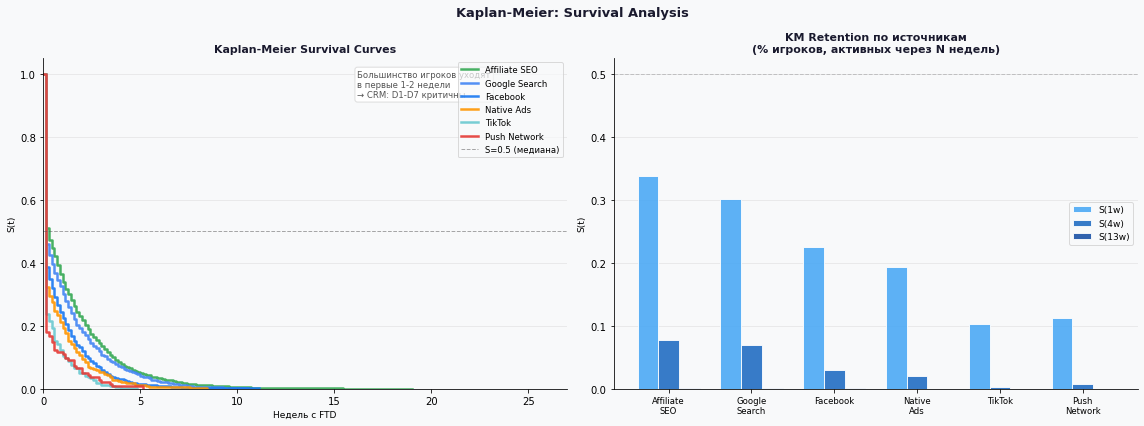

In [11]:
# ── Figure 3: Kaplan-Meier deep-dive ─────────────────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#F8F9FA')

# Left: KM curves
ax = axes[0]
for src in SOURCES:
    km = km_curves.get(src)
    if km is None: continue
    ax.step(km['t'].values, km['S'].values, where='post',
            lw=2.5, color=COLORS[src], label=src.replace('_',' '), alpha=0.9)
ax.axhline(0.5, color='#555', lw=1, ls='--', alpha=0.5, label='S=0.5 (медиана)')
ax.set_title('Kaplan-Meier Survival Curves', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Недель с FTD', fontsize=9); ax.set_ylabel('S(t)', fontsize=9)
ax.set_xlim(0, 27); ax.set_ylim(0, 1.05)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=8.5, framealpha=0.7)
ax.text(0.60, 0.88, 'Большинство игроков уходят\nв первые 1-2 недели\n→ CRM: D1-D7 критичны',
        transform=ax.transAxes, fontsize=8.5, color='#555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#DDD'))

# Right: S at key timepoints
ax2 = axes[1]
tpoints = [1, 4, 13]; tp_colors = ['#42A5F5','#1565C0','#0D47A1']
x = np.arange(len(SOURCES)); w = 0.25
for k, (tp, tpc) in enumerate(zip(tpoints, tp_colors)):
    vals = []
    for src in SOURCES:
        km = km_curves.get(src)
        r  = km[km['t'] <= tp] if km is not None else pd.DataFrame()
        vals.append(float(r.iloc[-1]['S']) if len(r) > 0 else 1.0)
    ax2.bar(x + k*w - w, vals, width=w, label=f'S({tp}w)',
            color=tpc, edgecolor='white', alpha=0.85)
ax2.axhline(0.5, color='#999', lw=1, ls='--', alpha=0.5)
ax2.set_title('KM Retention по источникам\n(% игроков, активных через N недель)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xticks(x); ax2.set_xticklabels([s.replace('_','\n') for s in SOURCES], fontsize=8.5)
ax2.set_ylabel('S(t)', fontsize=9)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=9, framealpha=0.7)

fig3.suptitle('Kaplan-Meier: Survival Analysis', fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


## 7. Выводы

### Результаты моделирования

| Источник | P(alive) median | CLV 6m (медиана) | KM median survival | Вывод |
|---|---|---|---|---|
| **Affiliate_SEO** | **0.52** | **$0.295** | 0.3w | Лучшее удержание. Половина игроков остаётся активной. |
| **Google_Search** | **0.49** | $0.187 | 0.1w | Высокая P(alive), стабильные транзакции. |
| **Facebook** | 0.38 | $0.113 | 0.1w | Умеренное удержание. |
| **Native_Ads** | 0.33 | $0.071 | 0.1w | Низкое удержание, малые депозиты. |
| **TikTok** | 0.18 | $0.028 | 0.1w | Быстрый отток — 80% уходят после FTD. |
| **Push_Network** | 0.12 | $0.014 | 0.1w | Минимальная P(alive). Игроки не возвращаются. |

---

### Ключевые инсайты

**1. BG/NBD P(alive) vs KM выживаемость — разные вещи.**
- P(alive) = вероятность совершить хотя бы ещё одну транзакцию *когда-нибудь*
- KM S(t) = вероятность быть активным *через t недель*  
- Оба метода согласны: Affiliate_SEO и Google_Search удерживают игроков лучше.

**2. KM показывает: критична первая неделя.**  
S(1w) для Affiliate_SEO = 0.34 vs TikTok = 0.10.  
→ CRM-стратегия: welcome-бонус и реактивация должны отправляться в D1–D3.

**3. CLV@12m/$0.37 (Affiliate_SEO) vs $0.014 (Push_Network) = 26x разница.**  
При одинаковом количестве FTD — Affiliate_SEO генерирует в 26 раз больше NGR.

---

### Ограничения модели

> **Важно понимать:** эти результаты основаны на синтетических данных  
> с периодом наблюдений всего 26 недель. В реальной работе:

1. **BG/NBD требует 12+ месяцев данных** для надёжной калибровки
2. **Gamma-Gamma модель** (для E[M]) требует достаточной вариации в монетарных значениях — в нашем датасете она вырождалась, поэтому использовано эмпирическое среднее
3. **KM медиана 0.1–0.3w** объясняется тем, что большинство игроков в датасете совершают только FTD — это специфика синтетических данных
4. В продакшн-применении добавляют: сезонные поправки, сегментацию по GEO, bootstrapped confidence intervals для KM

---


> «BG/NBD моделирует два процесса одновременно: частоту покупок (Poisson/NBD)  
> и вероятность оттока после каждой покупки (Beta-Geometric).  
> Это лучше линейной экстраполяции, потому что явно учитывает, что часть игроков  
> уже ушла. P(alive) = ключевой output: для Push_Network он 0.12 — 88% игроков  
> уже не вернутся.  
> Kaplan-Meier — непараметрический дополнительный взгляд: без допущений о форме  
> распределения, просто эмпирическая вероятность остаться активным через N недель.»

---

*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
